# Representing GPU Mesh Sharding with CuTe Layouts

On GPUs, device IDs typically follow a simple linear order (no topology permutation).
This makes the mesh layout a plain row-major `Layout` — no `Swizzle` needed.

## The setup

8 GPUs arranged as a 4×2 mesh, sharding an 8×4 array with `P('a', 'b')`.
Each GPU gets a contiguous 2×2 tile.

```
┌──────────┬──────────┐
│  GPU 0   │  GPU 1   │
├──────────┼──────────┤
│  GPU 2   │  GPU 3   │
├──────────┼──────────┤
│  GPU 4   │  GPU 5   │
├──────────┼──────────┤
│  GPU 6   │  GPU 7   │
└──────────┴──────────┘
```

Device IDs are in plain row-major order — no swizzling.

## Step 1: The device mesh

A 4×2 row-major layout directly maps mesh coordinates to GPU IDs: `(i,j) → 2i + j`.

In [ ]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout

device_mesh = Layout((4, 2), (2, 1))
print(device_mesh)

for i in range(4):
    row = [f"GPU {device_mesh(i, j)}" for j in range(2)]
    print(f"  row {i}: {row}")

(4, 2) : (2, 1)
  row 0: ['GPU 0', 'GPU 1']
  row 1: ['GPU 2', 'GPU 3']
  row 2: ['GPU 4', 'GPU 5']
  row 3: ['GPU 6', 'GPU 7']


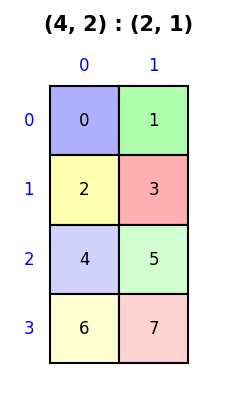

In [2]:
draw_layout(device_mesh, colorize=True)

## Step 2: Sharding an 8×4 array with contiguous local chunks

Each GPU gets a 2×2 row-major tile (PyTorch convention: biggest stride on the left).
`blocked_product` tiles the local chunk across device positions, pairing corresponding
modes: row with row, column with column.

In [3]:
# Local tile: 2x2 row-major (contiguous 4 elements per device)
local_tile = Layout((2, 2), (2, 1))

# blocked_product pairs modes: ((local_row, device_row), (local_col, device_col))
full = blocked_product(local_tile, device_mesh)
print("Layout:", full)
print()

# Print the 8x4 grid with device assignments
for i in range(8):
    offsets = [f"{full(i, j):2d}" for j in range(4)]
    devices = [f"d{full(i, j) // 4}" for j in range(4)]
    print(f"  row {i}: offsets [{', '.join(offsets)}]  devices [{', '.join(devices)}]")

Layout: ((2, 4), (2, 2)) : ((2, 8), (1, 4))

  row 0: offsets [ 0,  1,  4,  5]  devices [d0, d0, d1, d1]
  row 1: offsets [ 2,  3,  6,  7]  devices [d0, d0, d1, d1]
  row 2: offsets [ 8,  9, 12, 13]  devices [d2, d2, d3, d3]
  row 3: offsets [10, 11, 14, 15]  devices [d2, d2, d3, d3]
  row 4: offsets [16, 17, 20, 21]  devices [d4, d4, d5, d5]
  row 5: offsets [18, 19, 22, 23]  devices [d4, d4, d5, d5]
  row 6: offsets [24, 25, 28, 29]  devices [d6, d6, d7, d7]
  row 7: offsets [26, 27, 30, 31]  devices [d6, d6, d7, d7]


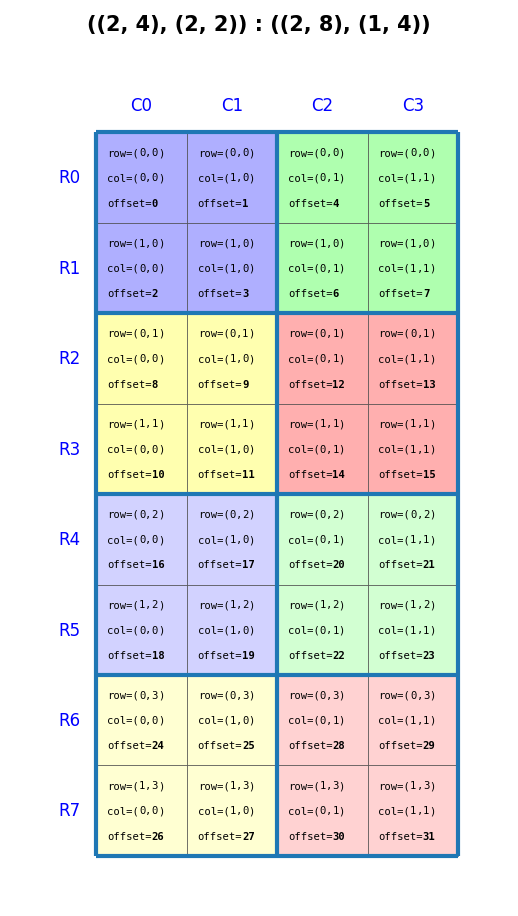

In [4]:
# Color by device ID
color = blocked_product(Layout((2, 2), (0, 0)), device_mesh)

draw_layout(full, flatten_hierarchical=False, color_layout=color, colorize=True, num_colors=8)

Each cell shows the hierarchical coordinates from `blocked_product`'s shape `((2, 4), (2, 2))`:

- **row** = `(local_row, device_row)` — first component is position within the 2×2 tile, second is which device row (0–3)
- **col** = `(local_col, device_col)` — first component is position within the tile, second is which device column (0–1)
- **offset** = linearized physical offset

Without the topology swizzle, offsets are simply `device_id * 4 + local_offset` in plain order.

## Step 3: Top-down — partitioning a global array with `zipped_divide`

`blocked_product` works **bottom-up**: given a local tile and a device mesh, it builds the global layout.
But what if we start with an existing global array and want to partition it into tiles?

`zipped_divide(global_array, tile_shape)` splits the array into `(tile, grid)`:
the first mode indexes within a tile, the second mode selects which tile (i.e., which device).

The key difference: `blocked_product` **creates** a layout where each device's chunk is contiguous,
while `zipped_divide` **preserves** the original memory layout (here, row-major).

In [ ]:
# Start with an 8x4 row-major global array
global_array = Layout((8, 4), (4, 1))
print("Global array:", global_array)
print()

# Partition into 2x2 tiles: result is ((tile), (grid))
tiled = zipped_divide(global_array, Layout((2, 2)))
print("zipped_divide result:", tiled)
print("  Shape:", tiled.shape)
print("  Mode 0 (tile):  shape", tiled.shape[0])
print("  Mode 1 (grid):  shape", tiled.shape[1])
print()

# Show what each grid position (device) gets
for g in range(8):
    tile_offsets = sorted([tiled(t, g) for t in range(4)])
    print(f"  grid {g} (device {g}): offsets {tile_offsets}")

Global array: (8, 4) : (4, 1)

zipped_divide result: ((2, 2), (4, 2)) : ((4, 1), (8, 2))
  Shape: ((2, 2), (4, 2))
  Mode 0 (tile):  shape (2, 2)
  Mode 1 (grid):  shape (4, 2)

  grid 0 (device 0): offsets [0, 1, 4, 5]
  grid 1 (device 1): offsets [8, 9, 12, 13]
  grid 2 (device 2): offsets [16, 17, 20, 21]
  grid 3 (device 3): offsets [24, 25, 28, 29]
  grid 4 (device 4): offsets [2, 3, 6, 7]
  grid 5 (device 5): offsets [10, 11, 14, 15]
  grid 6 (device 6): offsets [18, 19, 22, 23]
  grid 7 (device 7): offsets [26, 27, 30, 31]


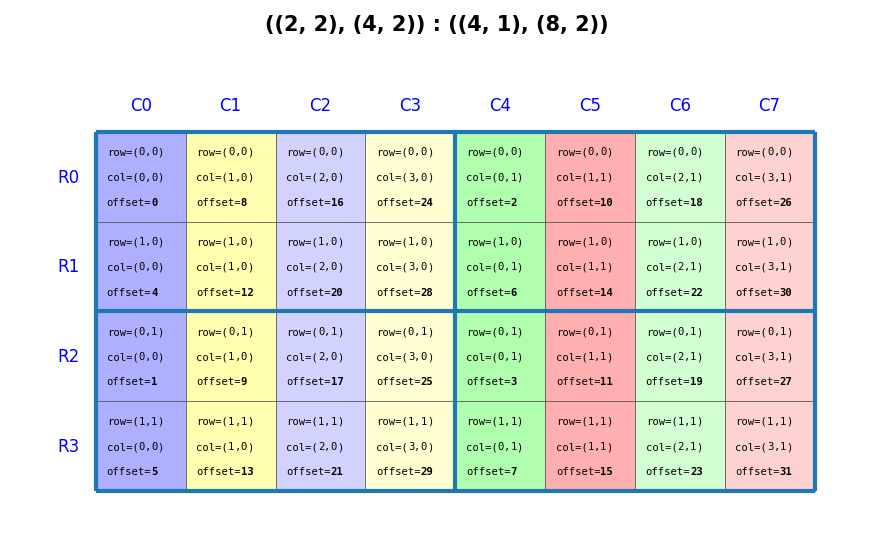

In [6]:
# Visualize: same 8x4 grid, but now from zipped_divide
color_td = zipped_divide(color, Layout((2, 2)))
draw_layout(tiled, flatten_hierarchical=False, color_layout=color_td, colorize=True, num_colors=8)

### Comparing the two approaches

| | `blocked_product` (bottom-up) | `zipped_divide` (top-down) |
|---|---|---|
| **Input** | local tile + device mesh | global array + tile shape |
| **Memory layout** | Each device's chunk is contiguous (offsets 0–3, 4–7, ...) | Preserves original row-major layout (a 2×2 tile spans rows 4 apart) |
| **Use case** | Designing a distributed memory layout | Partitioning an existing array across devices |

Both produce the same logical tiling (same 2×2 blocks assigned to same devices), but the physical offsets differ because the memory layouts are different.